In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import statsmodels.api as sm

In [2]:
train = pd.read_csv(r"C:\Users\shafaat hussain\Desktop\aiml\jet rail (TS)\Train.csv")
test = pd.read_csv(r"C:\Users\shafaat hussain\Desktop\aiml\jet rail (TS)\Test.csv")

In [3]:
train['Datetime'] = pd.to_datetime(train['Datetime'], format='%d-%m-%Y %H:%M')
test['Datetime'] = pd.to_datetime(test['Datetime'], format='%d-%m-%Y %H:%M')

In [4]:
df_all = pd.concat([train.set_index('Datetime'), test.set_index('Datetime')], keys=['train', 'test'])

C:\Users\shafaat hussain\AppData\Local\Temp\ipykernel_17876\1714807072.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_mean = train['Count'].resample('M').mean()


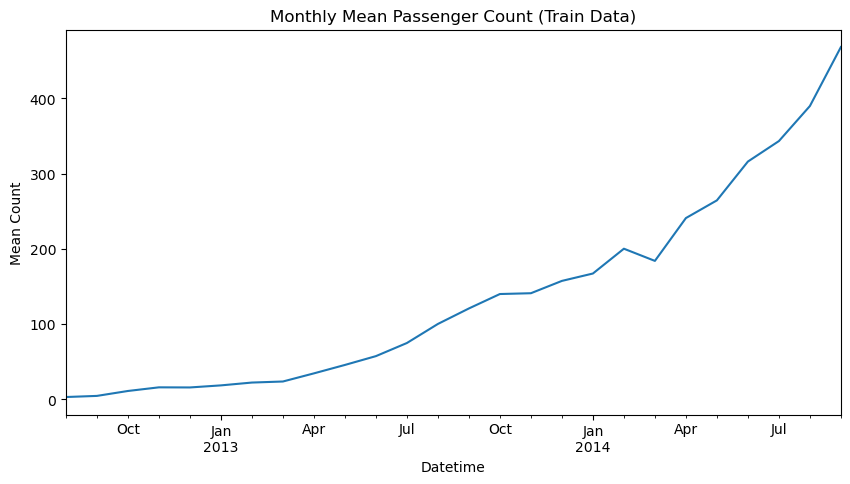

In [5]:
train.set_index('Datetime', inplace=True)
monthly_mean = train['Count'].resample('M').mean()

plt.figure(figsize=(10,5))
monthly_mean.plot()
plt.title('Monthly Mean Passenger Count (Train Data)')
plt.ylabel('Mean Count')
plt.show()

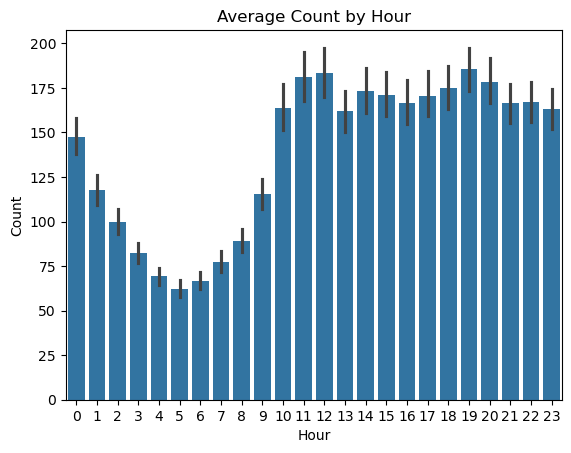

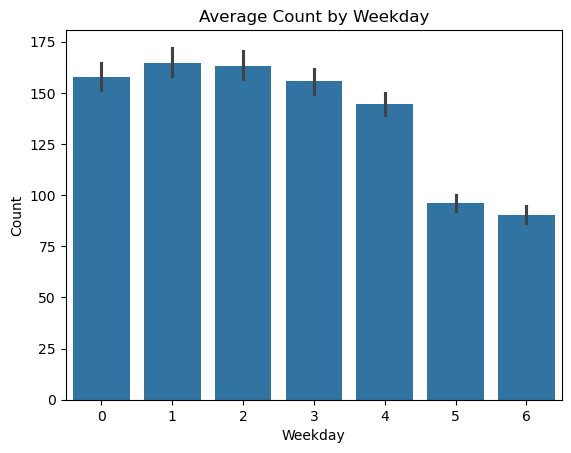

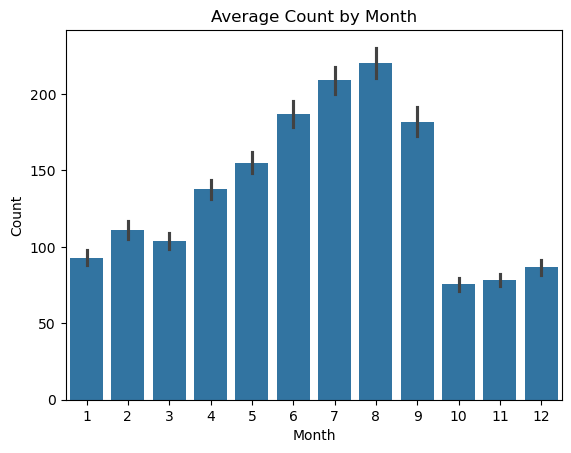

In [6]:
# Hourly average
train['Hour'] = train.index.hour
sns.barplot(x=train['Hour'], y=train['Count'])
plt.title('Average Count by Hour')
plt.show()

# Weekday average (0=Mon, 6=Sun)
train['Weekday'] = train.index.weekday
sns.barplot(x=train['Weekday'], y=train['Count'])
plt.title('Average Count by Weekday')
plt.show()

# Monthly average
train['Month'] = train.index.month
sns.barplot(x=train['Month'], y=train['Count'])
plt.title('Average Count by Month')
plt.show()

In [7]:
def add_features(df):
    dt_level = df.index.get_level_values(1)
    
    df['month'] = dt_level.month
    df['hour'] = dt_level.hour
    df['weekday'] = dt_level.weekday
    df['is_weekend'] = (df['weekday'] >= 5).astype(int)
    df['is_high_season'] = df['month'].isin([5,6,7,8,9,10]).astype(int)
    
    # Cyclic features
    df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
    df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)
    df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
    df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)
    
    min_dt = dt_level.min()
    df['trend'] = (dt_level - min_dt).days
    
    return df

df_all = add_features(df_all)

train = df_all.xs('train')
test = df_all.xs('test')

In [8]:
features = ['month', 'hour', 'weekday', 'is_weekend', 'is_high_season', 
            'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'trend']

X_train = train[features]
y_train = train['Count']
X_train = sm.add_constant(X_train)

model = sm.OLS(y_train, X_train).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Count   R-squared:                       0.727
Model:                            OLS   Adj. R-squared:                  0.727
Method:                 Least Squares   F-statistic:                     4878.
Date:                Sun, 16 Nov 2025   Prob (F-statistic):               0.00
Time:                        02:12:06   Log-Likelihood:            -1.0612e+05
No. Observations:               18288   AIC:                         2.123e+05
Df Residuals:                   18277   BIC:                         2.123e+05
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const            -40.5930      3.646    -11.

In [9]:
X_test = test[features]
X_test = sm.add_constant(X_test)
test['Count'] = model.predict(X_test)

# Clip negative, round to int
test['Count'] = np.clip(test['Count'], a_min=0, a_max=None).round().astype(int)

# Submission CSV
submission = pd.DataFrame({'ID': test['ID'], 'Count': test['Count']})
submission.to_csv('submission.csv', index=False)
print("\nSubmission saved as 'submission.csv'")
print(submission.head())


Submission saved as 'submission.csv'
                        ID  Count
Datetime                         
2014-09-26 00:00:00  18288    368
2014-09-26 01:00:00  18289    356
2014-09-26 02:00:00  18290    347
2014-09-26 03:00:00  18291    340
2014-09-26 04:00:00  18292    336


C:\Users\shafaat hussain\AppData\Local\Temp\ipykernel_17876\813578191.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['Count'] = model.predict(X_test)
C:\Users\shafaat hussain\AppData\Local\Temp\ipykernel_17876\813578191.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['Count'] = np.clip(test['Count'], a_min=0, a_max=None).round().astype(int)


In [10]:
# Sum predicted monthly counts (approximate users)
test_monthly = test['Count'].resample('M').sum()
print("\nPredicted Monthly Totals (Sep 2014 - Apr 2015):\n", test_monthly)

# Extrapolate to 18 months (add ~11 more months, assuming linear growth)
last_month = test_monthly.iloc[-1]
growth_rate = (monthly_mean.iloc[-1] / monthly_mean.iloc[0]) ** (1/len(monthly_mean)) - 1  # Avg monthly growth
extrapolated = [last_month * (1 + growth_rate)**i for i in range(1, 12)]
total_18m = test_monthly.sum() + sum(extrapolated)

print(f"\nEstimated 18-Month Total Users: {total_18m:.0f}")
if total_18m > 1_000_000 * 18:
    print("Recommendation: Invest - Exceeds 1M monthly average.")
else:
    print("Recommendation: Do not invest - Below 1M monthly average.")


Predicted Monthly Totals (Sep 2014 - Apr 2015):
 Datetime
2014-09-30     44783
2014-10-31    286326
2014-11-30    276301
2014-12-31    286983
2015-01-31    296209
2015-02-28    268411
2015-03-31    303916
2015-04-30    265226
Freq: ME, Name: Count, dtype: int32

Estimated 18-Month Total Users: 13308080
Recommendation: Do not invest - Below 1M monthly average.


C:\Users\shafaat hussain\AppData\Local\Temp\ipykernel_17876\2100947314.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  test_monthly = test['Count'].resample('M').sum()
